In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

Loading Dataset

In [3]:
df=pd.read_csv(r"C:\Users\bawa\Desktop\python.py\netflix_titles.csv")
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Dataset Overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [5]:
df.shape

(8807, 12)

In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Length: 8807, dtype: bool

Handling Missing Values

In [10]:
df.fillna({"country": "unknown"}, inplace=True)
df.fillna({"rating": "unknown"}, inplace=True)
df.fillna({"duration": "unknown"}, inplace=True)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


Convertion into Date columns

In [11]:
df['date_added']=pd.to_datetime(df['date_added'], errors='coerce')

In [12]:
df['year_added']=df['date_added'].dt.year
df['year_added'].head()

0    2021.0
1    2021.0
2    2021.0
3    2021.0
4    2021.0
Name: year_added, dtype: float64

Movies vs TV Shows(Trends and Top genre)

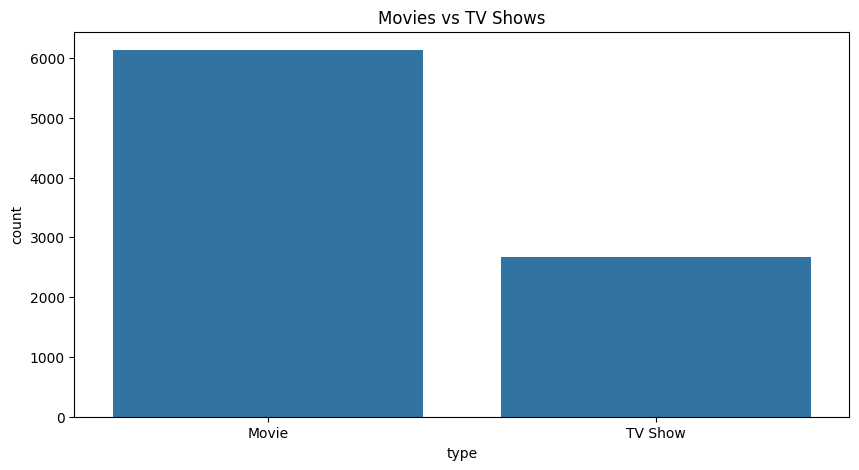

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()
df['type'].value_counts()

Content Growth Over Time

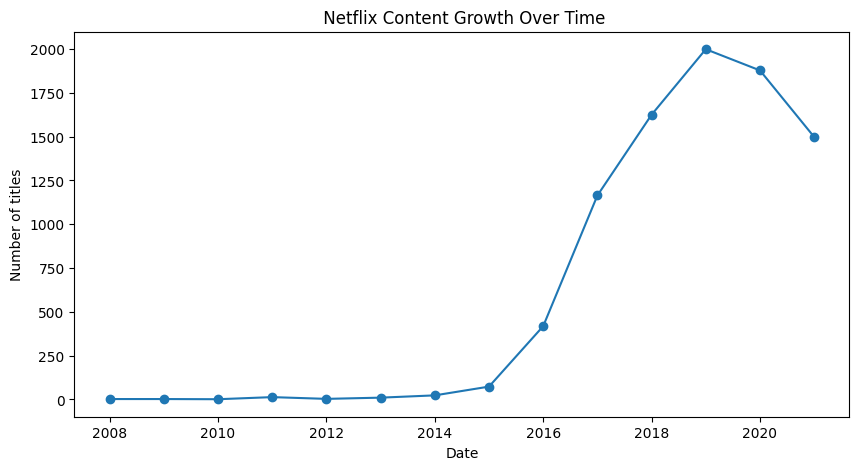

In [14]:
content_growth= df['year_added'].value_counts().sort_index()
plt.figure(figsize=(10,5))
content_growth.plot(kind='line', marker='o')
plt.title(" Netflix Content Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Number of titles")
plt.show()

Release Year Trend

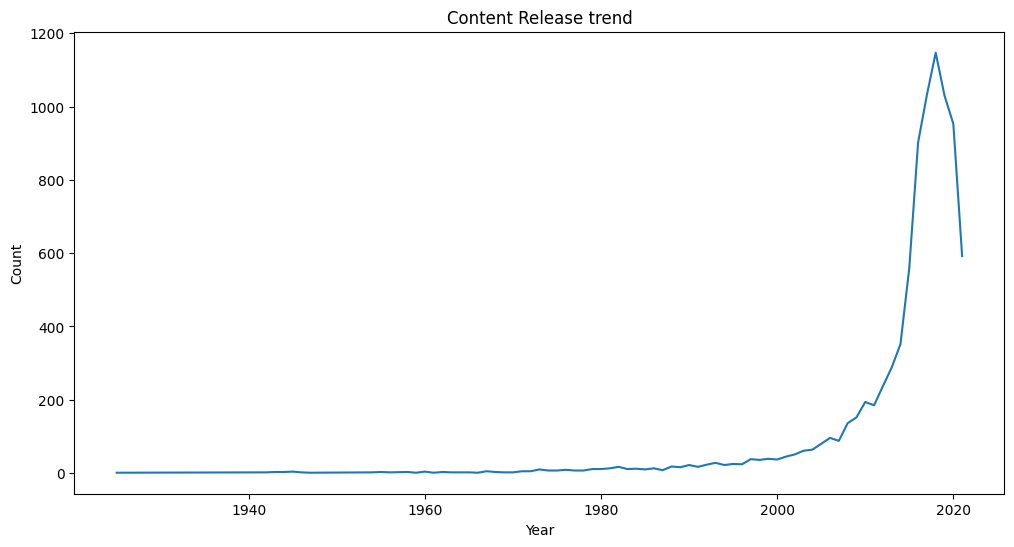

In [15]:
release_trend=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
release_trend.plot(kind='line')
plt.title("Content Release trend")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

Top 10 Genres

In [16]:
genres=df['listed_in'].str.split(',', expand=False)
all_genres=genres.explode()
top_genres=all_genres.value_counts().head(10)
top_genres

listed_in
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64

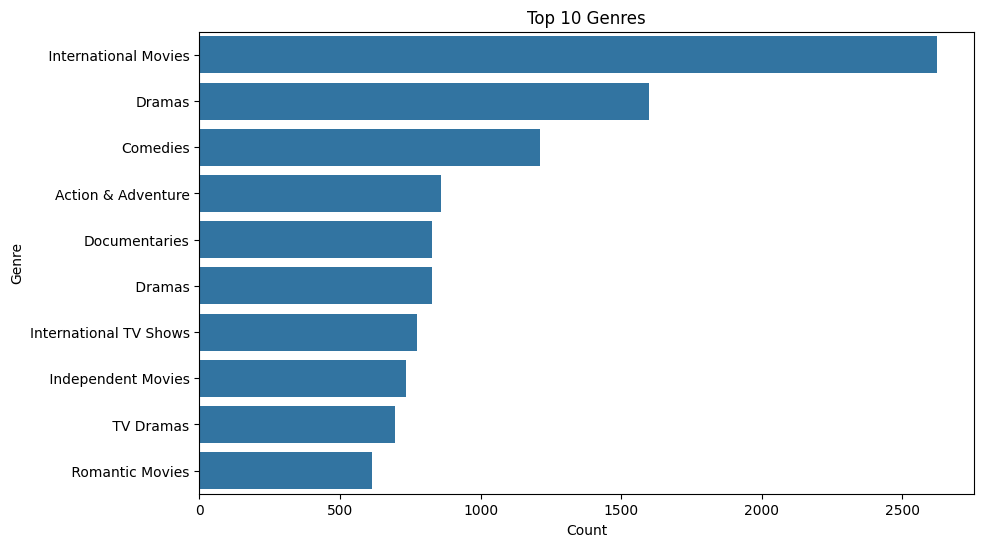

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

Top 10 Release Years

In [19]:
top_years= df['release_year'].value_counts().head(10)
top_years

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

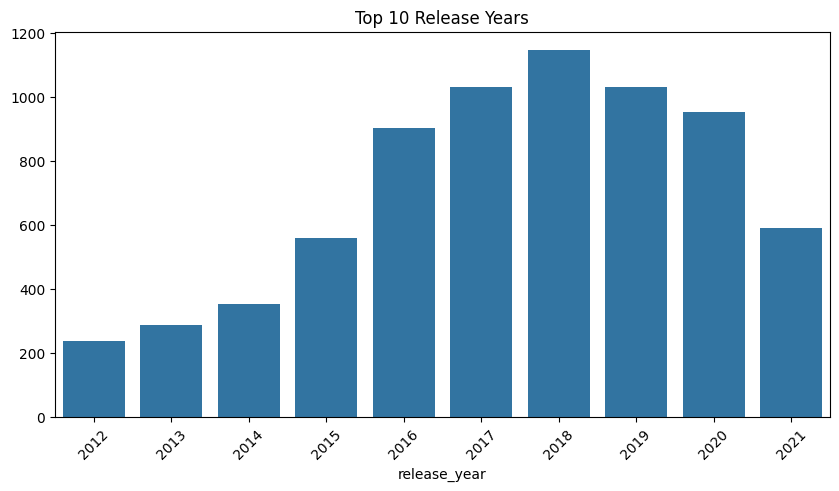

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_years.index, y=top_years.values)
plt.title("Top 10 Release Years")
plt.xticks(rotation=45)
plt.show()

Runtime Distribution(Movies only)

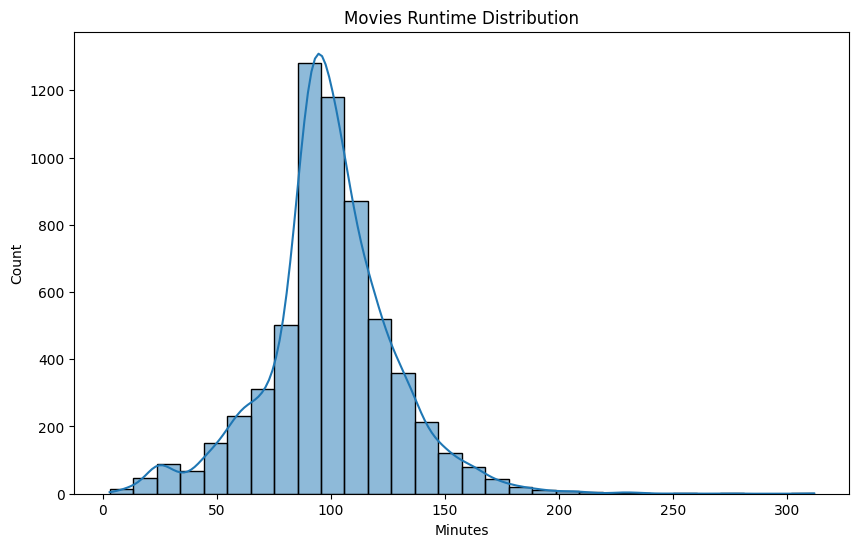

In [29]:
movies=df[df['type'] == 'Movie'].copy()
movies['duration_minutes']=(movies['duration'].str.extract('(\\d+)').astype(float))

plt.figure(figsize=(10,6))
sns.histplot(movies['duration_minutes'], bins=30, kde=True)
plt.title("Movies Runtime Distribution")
plt.xlabel("Minutes")
plt.show()

Movies vs Tv Shows Percentage

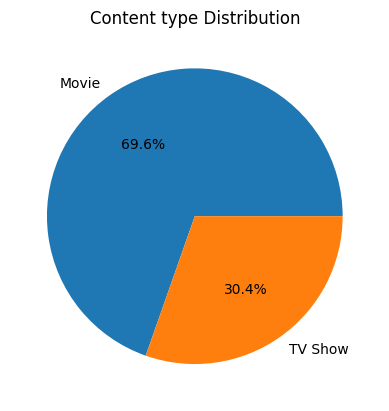

In [31]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Content type Distribution")
plt.ylabel("")
plt.show()

In [32]:
print("Netflix Dataset Summary")

print(f"Total Titles: {len(df)}")

print(f"Movies: {(df['type']=='Movie').sum()}")

print(f"TV Shows: {(df['type']=='TV Show').sum()}")

print(f"Top Genre: {top_genres.index[0]}")

print(f"Most Common Release Year: {top_years.index[0]}")

Netflix Dataset Summary
Total Titles: 8807
Movies: 6131
TV Shows: 2676
Top Genre:  International Movies
Most Common Release Year: 2018
